#Data

In [ ]:
from IPython.display import display, HTML

# ============================================================
# Data Dictionary — Hotel Channel Profitability Dataset
# สไตล์ตาม Dark Theme เหมือนตัวอย่าง
# ============================================================

data_dict = [
    # (Attribute, Description_TH, Data_Type, Valid_Range_Example)

    # ── fact_bookings ──
    ('booking_id',          'รหัสออเดอร์ที่ใช้ระบุแต่ละการจอง',
                             'Nominal',                'BK10001, BK15000'),
    ('booking_date',        'วันที่มีการสั่งจอง',
                             'Interval (Date)',        '2024-01-01 ถึง 2024-12-31'),
    ('check_in_date',       'วันที่ Check-in เข้าพัก',
                             'Interval (Date)',        '2024-01-01 ถึง 2025-01-30'),
    ('channel_id',          'รหัสช่องทางการจอง (Foreign Key)',
                             'Nominal',                'CH_01 ถึง CH_08'),
    ('rate_code_id',        'รหัสประเภทอัตราค่าห้อง (Foreign Key)',
                             'Nominal',                'RT_BAR, RT_CORP, RT_PROMO, RT_NET, RT_PKG, RT_WALK, RT_GOVT'),
    ('gross_room_revenue',  'รายได้ห้องพักก่อนหักค่า Commission (บาท)',
                             'Ratio (Continuous)',     '[1,787.82, 39,699.77] THB'),
    ('commission_amount',   'ค่า Commission ที่จ่ายให้ช่องทางการจอง (บาท)',
                             'Ratio (Continuous)',     '[0, 6,003.80] THB (0 = Direct/Net Rate)'),
    ('net_room_revenue',    'รายได้ห้องพักหลังหักค่า Commission (บาท)',
                             'Ratio (Continuous)',     '[1,609.77, 39,699.77] THB'),
    ('status',              'สถานะของการจอง',
                             'Nominal',                'Checked-Out, Cancelled, Confirmed'),
    ('net_margin',          'อัตราส่วน Net/Gross Revenue (Gross ÷ Net)',
                             'Ratio (Continuous)',     '[1.000, 1.250] — Direct=1.000, GDS=1.250'),
    ('channel_type',        'ประเภทของช่องทางการจอง (Category)',
                             'Nominal',                'OTA, Direct, Corporate, Offline, GDS'),
    ('channel_name',        'ชื่อของช่องทางการจอง',
                             'Nominal',                'Booking.com, Expedia, Agoda, Direct Website, Walk-in, Corporate Direct, Travel Agency, GDS (Amadeus)'),
    ('Cancelled Flag',      'Flag = 1 หากการจองถูกยกเลิก, 0 หากไม่ใช่',
                             'Nominal (Binary)',       '0 = ไม่ยกเลิก, 1 = ยกเลิก'),
    ('Checked-Out Flag',    'Flag = 1 หากการจอง Checked-Out สำเร็จ, 0 หากไม่ใช่',
                             'Nominal (Binary)',       '0 = ยังไม่ Check-out, 1 = Check-out แล้ว'),
    ('Net_revenue',         'รายได้สุทธิที่เกิดขึ้นจริง (0 หากถูกยกเลิก)',
                             'Ratio (Continuous)',     '0 (Cancelled/Confirmed) หรือ = net_room_revenue'),
    ('Gross Revenue',       'รายได้รวมที่เกิดขึ้นจริง (0 หากถูกยกเลิก)',
                             'Ratio (Continuous)',     '0 (Cancelled/Confirmed) หรือ = gross_room_revenue'),

    # ── dim_channels ──
    ('channel_id',          '[dim_channels] รหัสช่องทางการจอง (Primary Key)',
                             'Nominal',                'CH_01 ถึง CH_08'),
    ('channel_name',        '[dim_channels] ชื่อช่องทางการจอง',
                             'Nominal',                'Booking.com, Expedia, Agoda, Direct Website, Walk-in, Corporate Direct, Travel Agency, GDS (Amadeus)'),
    ('channel_type',        '[dim_channels] ประเภทของช่องทาง',
                             'Nominal',                'OTA, Direct, Corporate, Offline, GDS'),
    ('commission_model',    '[dim_channels] รูปแบบการคิด Commission',
                             'Nominal',                'Percentage, Flat Fee'),
    ('default_commission_rate','[dim_channels] อัตรา Commission มาตรฐาน',
                             'Ratio (Continuous)',     '0.00 (Direct) ถึง 0.20 (GDS)'),
    ('contract_owner',      '[dim_channels] ผู้รับผิดชอบสัญญาช่องทาง',
                             'Nominal',                'Somchai P., Nattaya K., Wichai S.'),

    # ── dim_rate_codes ──
    ('rate_code_id',        '[dim_rate_codes] รหัสประเภทราคา (Primary Key)',
                             'Nominal',                'RT_BAR, RT_CORP, RT_PKG, RT_NET, RT_PROMO, RT_WALK, RT_GOVT'),
    ('rate_name',           '[dim_rate_codes] ชื่อประเภทราคา',
                             'Nominal',                'Best Available Rate, Corporate Rate, Package Rate, Net Rate (OTA), Promotional Rate, Walk-in Rate, Government Rate'),
    ('is_commissionable',   '[dim_rate_codes] ประเภทราคานี้คิด Commission หรือไม่',
                             'Nominal (Boolean)',      'True = คิด Commission, False = ไม่คิด (Net/Walk-in/Govt)'),
]

# ──────────── Build HTML ────────────
rows_html = ''
section_headers = {
    0  : 'fact_bookings — ตารางข้อมูลการจองหลัก (5,000 rows)',
    16 : 'dim_channels — ตารางข้อมูลช่องทาง (8 rows)',
    22 : 'dim_rate_codes — ตารางรหัสประเภทราคา (7 rows)',
}

for i, (attr, desc, dtype, example) in enumerate(data_dict):
    # Section header row
    if i in section_headers:
        rows_html += f'''
        <tr>
          <td colspan="4" style="
            background:#1A6B4A; color:white; font-weight:bold;
            font-size:13px; padding:10px 16px; letter-spacing:0.5px;
          ">📁 {section_headers[i]}</td>
        </tr>
        '''

    bg = '#2C3E50' if i % 2 == 0 else '#34495E'
    tag_color = '#27AE60'
    if 'dim_channels' in desc:   tag_color = '#2980B9'
    if 'dim_rate_codes' in desc: tag_color = '#8E44AD'

    # Data type badge color
    if 'Nominal'   in dtype: badge_c = '#2980B9'
    elif 'Ordinal' in dtype: badge_c = '#8E44AD'
    elif 'Ratio'   in dtype: badge_c = '#16A085'
    elif 'Interval'in dtype: badge_c = '#E67E22'
    elif 'Boolean' in dtype: badge_c = '#C0392B'
    elif 'Binary'  in dtype: badge_c = '#C0392B'
    else:                    badge_c = '#7F8C8D'

    rows_html += f'''
    <tr style="background:{bg}; color:#ECF0F1;">
      <td style="padding:10px 14px; font-weight:bold; font-size:13px;
                 border-right:1px solid #1A252F; white-space:nowrap;
                 color:#F8C471;">{attr}</td>
      <td style="padding:10px 14px; font-size:13px; border-right:1px solid #1A252F;">{desc}</td>
      <td style="padding:10px 14px; text-align:center; border-right:1px solid #1A252F; white-space:nowrap;">
        <span style="background:{badge_c}; color:white; padding:3px 9px;
                     border-radius:12px; font-size:11.5px; font-weight:bold;">{dtype}</span>
      </td>
      <td style="padding:10px 14px; font-size:12px; color:#BDC3C7;">{example}</td>
    </tr>
    '''

html = f'''
<style>
  .dd-table {{ border-collapse:collapse; width:100%; font-family:'Segoe UI',Arial,sans-serif; }}
  .dd-table td {{ border-bottom:1px solid #1A252F; vertical-align:middle; }}
</style>
<div style="background:#1A252F; border-radius:10px; padding:20px 20px 8px 20px;
            box-shadow:0 4px 15px rgba(0,0,0,0.4); margin-bottom:10px;">
  <h2 style="color:white; font-family:'Segoe UI',Arial,sans-serif;
             margin:0 0 16px 0; font-size:20px; letter-spacing:0.5px;">
    📖 Data Dictionary &nbsp;
    <span style="background:#F39C12; padding:3px 10px; border-radius:6px;
                 font-size:13px; font-weight:bold; color:#1A252F;">Hotel Channel Profitability</span>
  </h2>
  <table class="dd-table">
    <thead>
      <tr style="background:#0D1B2A;">
        <th style="padding:12px 14px; text-align:left; color:#F39C12;
                   font-size:14px; font-weight:bold; white-space:nowrap;">Attribute</th>
        <th style="padding:12px 14px; text-align:left; color:#F39C12; font-size:14px; font-weight:bold;">Description (คำอธิบาย)</th>
        <th style="padding:12px 14px; text-align:center; color:#F39C12; font-size:14px; font-weight:bold; white-space:nowrap;">Data Type</th>
        <th style="padding:12px 14px; text-align:left; color:#F39C12; font-size:14px; font-weight:bold;">Valid Range / Example</th>
      </tr>
    </thead>
    <tbody>
      {rows_html}
    </tbody>
  </table>
  <p style="color:#7F8C8D; font-size:11px; margin:10px 0 4px 4px;">
    Dataset: 5,000 bookings | 8 channels | Period: 2024-01-01 to 2024-12-31 | Currency: THB
  </p>
</div>
'''

display(HTML(html))

# 🏨 Hotel Channel Profitability — Full Analysis
**ข้อมูล:** fact_bookingswork H2 (2) + dim_channels | **สกุลเงิน:** THB | **ช่วงเวลา:** 2024-01-01 ถึง 2024-12-31

> ⚠️ **หมายเหตุสำคัญ:** Net Margin ที่ใช้ในการวิเคราะห์นี้ = `net_room_revenue / gross_room_revenue` (ตรงกับ Pivot ในไฟล์ Excel)

| Hypothesis | คำถาม |
|---|---|
| **H1** | Direct channels มี Net ADR และ Net Margin สูงกว่า OTA |
| **H2** | OTA มีอัตราการยกเลิกสูงกว่า → รายได้จริงลดลง |
| **H3** | Commission สูง → Net Revenue ต่อ booking ต่ำกว่า |
| **Q1** | Net ADR สูง → Volume มากหรือน้อย? |
| **Q2** | OTA vs Direct ต่างกันกี่ % ใน Net Margin? |
| **Q3** | Cancellation ส่งผลต่อ Net Revenue มากแค่ไหน? |
| **Q4** | Commission สูง → Net ADR ต่ำ จริงหรือไม่? |
| **Q5** | Cancellation ส่งผลต่อ Net Margin ของ booking ที่สำเร็จจริงแค่ไหน? |
| **Q6** | ถ้าตัด OTA ออก → รายได้หายเท่าไร vs Margin ดีขึ้นเท่าไร? |

In [ ]:
!pip install openpyxl matplotlib seaborn -q

In [ ]:
from google.colab import files
uploaded = files.upload()  # อัปโหลด hotel_channel_profitability_v2__2_.xlsx

Saving hotel_channel_profitability_v2.xlsx to hotel_channel_profitability_v2.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'axes.grid.axis'   : 'y',
    'grid.alpha'       : 0.25,
    'grid.linestyle'   : '--',
})
BG = '#F8F9FA'

# Colors ตรงกับประเภท channel
TYPE_COLOR = {
    'OTA'      : '#E74C3C',
    'Direct'   : '#27AE60',
    'Corporate': '#2E86C1',
    'Offline'  : '#E67E22',
    'GDS'      : '#8E44AD',
}
NAME_COLOR = {
    'Booking.com'    : '#E74C3C',
    'Expedia'        : '#C0392B',
    'Agoda'          : '#FF7675',
    'Direct Website' : '#27AE60',
    'Walk-in'        : '#1E8449',
    'Corporate Direct': '#2E86C1',
    'GDS (Amadeus)'  : '#8E44AD',
    'Travel Agency'  : '#E67E22',
}

def fmt_thb(x, _=None): return f'฿{x/1000:.0f}k'
def fmt_pct(x, _=None): return f'{x:.1%}'
def save_fig(name):
    plt.savefig(f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ บันทึก: {name}.png')

print('✅ Setup เรียบร้อย')

✅ Setup เรียบร้อย


In [ ]:
# ============================================================
# โหลดข้อมูลและคำนวณ metrics ที่ถูกต้อง
# ============================================================
fname = list(uploaded.keys())[0]

# Sheet หลัก: fact_bookingswork H2 (2) — มี Cancelled Flag และ Checked-Out Flag
df  = pd.read_excel(fname, sheet_name='fact_bookingswork H2 (2)')
dim = pd.read_excel(fname, sheet_name='dim_channels')

df = df.merge(dim[['channel_name','default_commission_rate','commission_model']], on='channel_name', how='left')

# ⚠️ Net Margin ที่ถูกต้อง = net_room_revenue / gross_room_revenue
# (ตรงกับ Pivot ใน Excel: Sheet6, H1_NetADR_NetMargin, H2 sheet)
df['net_margin_pct'] = df['net_room_revenue'] / df['gross_room_revenue']

# Channel-level summary
ch = df.groupby(['channel_name','channel_type']).agg(
    total          = ('booking_id',              'count'),
    cancelled      = ('Cancelled Flag',           'sum'),
    checked_out    = ('Checked-Out Flag',         'sum'),
    avg_net_adr    = ('net_room_revenue',         'mean'),
    avg_gross_adr  = ('gross_room_revenue',       'mean'),
    sum_net        = ('net_room_revenue',         'sum'),
    sum_gross      = ('gross_room_revenue',       'sum'),
    avg_commission = ('commission_amount',        'mean'),
    comm_rate      = ('default_commission_rate',  'first'),
).reset_index()
ch['cancel_rate']   = ch['cancelled']   / ch['total']
ch['checkout_rate'] = ch['checked_out'] / ch['total']
ch['net_margin_pct'] = ch['sum_net'] / ch['sum_gross']   # ตรงกับ Sheet6

# Checked-Out only net margin
co_only = df[df['Checked-Out Flag']==1].groupby('channel_name').agg(
    sum_net_co    = ('net_room_revenue',  'sum'),
    sum_gross_co  = ('gross_room_revenue','sum'),
).reset_index()
co_only['margin_co'] = co_only['sum_net_co'] / co_only['sum_gross_co']
ch = ch.merge(co_only, on='channel_name', how='left')

# Channel-type summary
ct = df.groupby('channel_type').agg(
    total      = ('booking_id',        'count'),
    cancelled  = ('Cancelled Flag',    'sum'),
    checked_out= ('Checked-Out Flag',  'sum'),
    avg_net    = ('net_room_revenue',  'mean'),
    sum_net    = ('net_room_revenue',  'sum'),
    sum_gross  = ('gross_room_revenue','sum'),
).reset_index()
ct['cancel_rate']    = ct['cancelled']    / ct['total']
ct['net_margin_pct'] = ct['sum_net']      / ct['sum_gross']   # ตรงกับ Sheet6

print('📊 ตรวจสอบ Net Margin % (ต้องตรงกับ Sheet6 ใน Excel):')
verify = ch[['channel_name','channel_type','total','cancelled','checked_out',
              'cancel_rate','avg_net_adr','net_margin_pct','comm_rate']].copy()
verify['cancel_rate']    = verify['cancel_rate'].map('{:.4f}'.format)
verify['net_margin_pct'] = verify['net_margin_pct'].map('{:.6f}'.format)
print(verify.to_string(index=False))

print(f'\nGrand Total Net: ฿{df["net_room_revenue"].sum():,.2f}')
print(f'Grand Total Gross: ฿{df["gross_room_revenue"].sum():,.2f}')
print(f'Overall Net Margin: {df["net_room_revenue"].sum()/df["gross_room_revenue"].sum():.6f} (Excel: 0.926554)')

📊 ตรวจสอบ Net Margin % (ต้องตรงกับ Sheet6 ใน Excel):
    channel_name channel_type  total  cancelled  checked_out cancel_rate  avg_net_adr net_margin_pct  comm_rate
           Agoda          OTA    892        199          557      0.2231  7270.041816       0.937818       0.12
     Booking.com          OTA   1120        332          642      0.2964  7469.113518       0.901137       0.15
Corporate Direct    Corporate    582         61          439      0.1048  7414.619055       0.974283       0.05
  Direct Website       Direct    757         90          562      0.1189  9395.313501       1.000000       0.00
         Expedia          OTA    784        205          461      0.2615  7641.583048       0.879251       0.18
   GDS (Amadeus)          GDS    314         57          209      0.1815  6607.330159       0.800000       0.20
   Travel Agency      Offline    349         52          251      0.1490  7892.755158       0.900000       0.10
         Walk-in       Direct    202         18    

---
## 📊 H1: Direct มี Net ADR & Net Margin สูงกว่า OTA
**กราฟ: Grouped Bar Chart** — Gross ADR vs Net ADR พร้อม Net Margin %

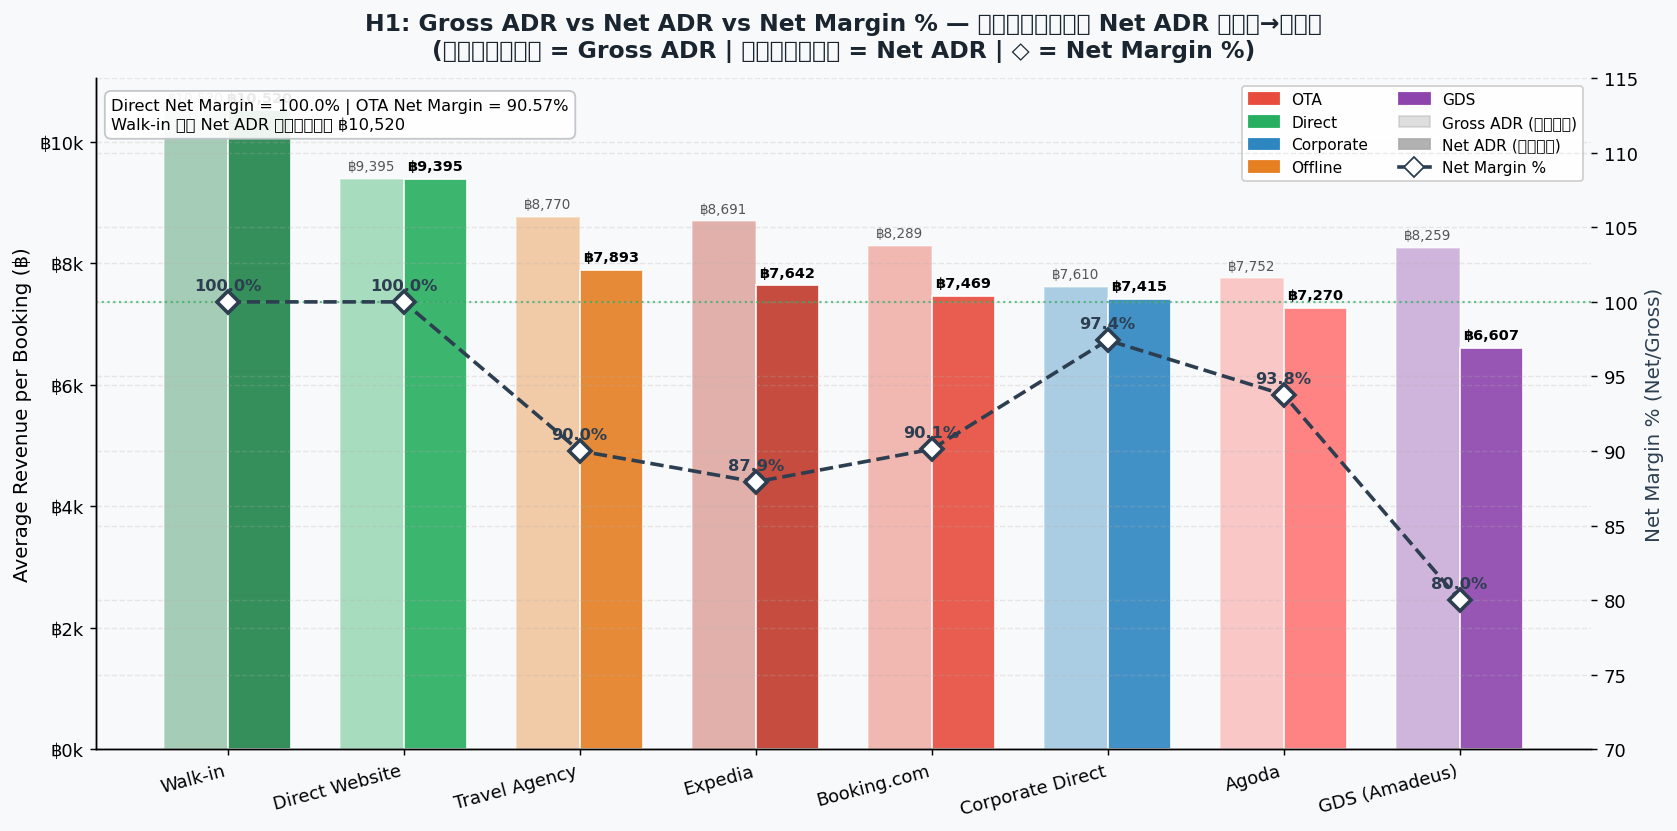

✅ บันทึก: H1_ADR_and_NetMargin.png


In [ ]:
# ข้อมูลจาก H1_NetADR_NetMargin sheet (Excel)
# avg_net_adr: CH_01=7469.11, CH_02=7641.58, CH_03=7270.04, CH_04=9395.31,
#              CH_05=10520.39, CH_06=7414.62, CH_07=7892.76, CH_08=6607.33
# Net Margin %: Direct=100%, Corporate=97.43%, OTA ~90-94%, Offline=90%, GDS=80%

ch_h1 = ch.sort_values('avg_net_adr', ascending=False).reset_index(drop=True)
labels  = ch_h1['channel_name'].tolist()
colors  = [NAME_COLOR.get(n,'#95A5A6') for n in labels]
x = np.arange(len(labels))
w = 0.36

fig, ax1 = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor(BG)
ax1.set_facecolor(BG)

# Gross ADR (อ่อน)
b_gross = ax1.bar(x - w/2, ch_h1['avg_gross_adr'], w,
                  color=colors, alpha=0.38, edgecolor='white', linewidth=1, label='Gross ADR')
# Net ADR (เข้ม)
b_net   = ax1.bar(x + w/2, ch_h1['avg_net_adr'],   w,
                  color=colors, alpha=0.90, edgecolor='white', linewidth=1, label='Net ADR')

# Label ค่าบน bar
for bar, val in zip(b_gross, ch_h1['avg_gross_adr']):
    ax1.text(bar.get_x()+bar.get_width()/2, val+90,
             f'฿{val:,.0f}', ha='center', va='bottom', fontsize=7.5, color='#555')
for bar, val in zip(b_net, ch_h1['avg_net_adr']):
    ax1.text(bar.get_x()+bar.get_width()/2, val+90,
             f'฿{val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Net Margin % บน secondary axis
ax2 = ax1.twinx()
ax2.plot(x, ch_h1['net_margin_pct']*100, 'D--',
         color='#2C3E50', lw=2, markersize=9,
         markerfacecolor='white', markeredgewidth=2,
         label='Net Margin %', zorder=5)
for xi, m in zip(x, ch_h1['net_margin_pct']):
    ax2.text(xi, m*100 + 0.6, f'{m:.1%}',
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2C3E50')
ax2.set_ylim(70, 115)
ax2.set_ylabel('Net Margin % (Net/Gross)', fontsize=11, color='#2C3E50')
ax2.axhline(100, color='#27AE60', lw=1.2, linestyle=':', alpha=0.7)

ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=15, ha='right', fontsize=10)
ax1.set_ylabel('Average Revenue per Booking (฿)', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_thb))
ax1.set_title(
    'H1: Gross ADR vs Net ADR vs Net Margin % — เรียงตาม Net ADR สูง→ต่ำ\n'
    '(แถบอ่อน = Gross ADR | แถบเข้ม = Net ADR | ◇ = Net Margin %)',
    fontsize=13, fontweight='bold', color='#1A252F', pad=12)

legend_type = [mpatches.Patch(color=TYPE_COLOR.get(t,'#95A5A6'), label=t)
               for t in ['OTA','Direct','Corporate','Offline','GDS']]
legend_fmt  = [mpatches.Patch(color='#AAAAAA', alpha=0.38, label='Gross ADR (อ่อน)'),
               mpatches.Patch(color='#AAAAAA', alpha=0.90, label='Net ADR (เข้ม)'),
               plt.Line2D([0],[0], marker='D', color='#2C3E50', lw=2,
                          markerfacecolor='white', markersize=8, label='Net Margin %')]
ax1.legend(handles=legend_type+legend_fmt, fontsize=8.5, ncol=2,
           framealpha=0.9, loc='upper right')

# Insight box
dir_margin = ch[ch['channel_type']=='Direct']['net_margin_pct'].mean()
ota_margin = (df[df['channel_type']=='OTA']['net_room_revenue'].sum() /
              df[df['channel_type']=='OTA']['gross_room_revenue'].sum())
ax1.text(0.01, 0.97,
    f'Direct Net Margin = {dir_margin:.1%} | OTA Net Margin = {ota_margin:.2%}\n'
    f'Walk-in มี Net ADR สูงสุด ฿{ch[ch["channel_name"]=="Walk-in"]["avg_net_adr"].values[0]:,.0f}',
    transform=ax1.transAxes, va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#BDC3C7', alpha=0.92))

plt.tight_layout()
save_fig('H1_ADR_and_NetMargin')

---
## ❓ Q1: Net ADR สูง → Volume มากหรือน้อย? + Q2: OTA vs Direct % Net Margin
**กราฟ: Dual-Axis + Horizontal Bar พร้อม % difference**

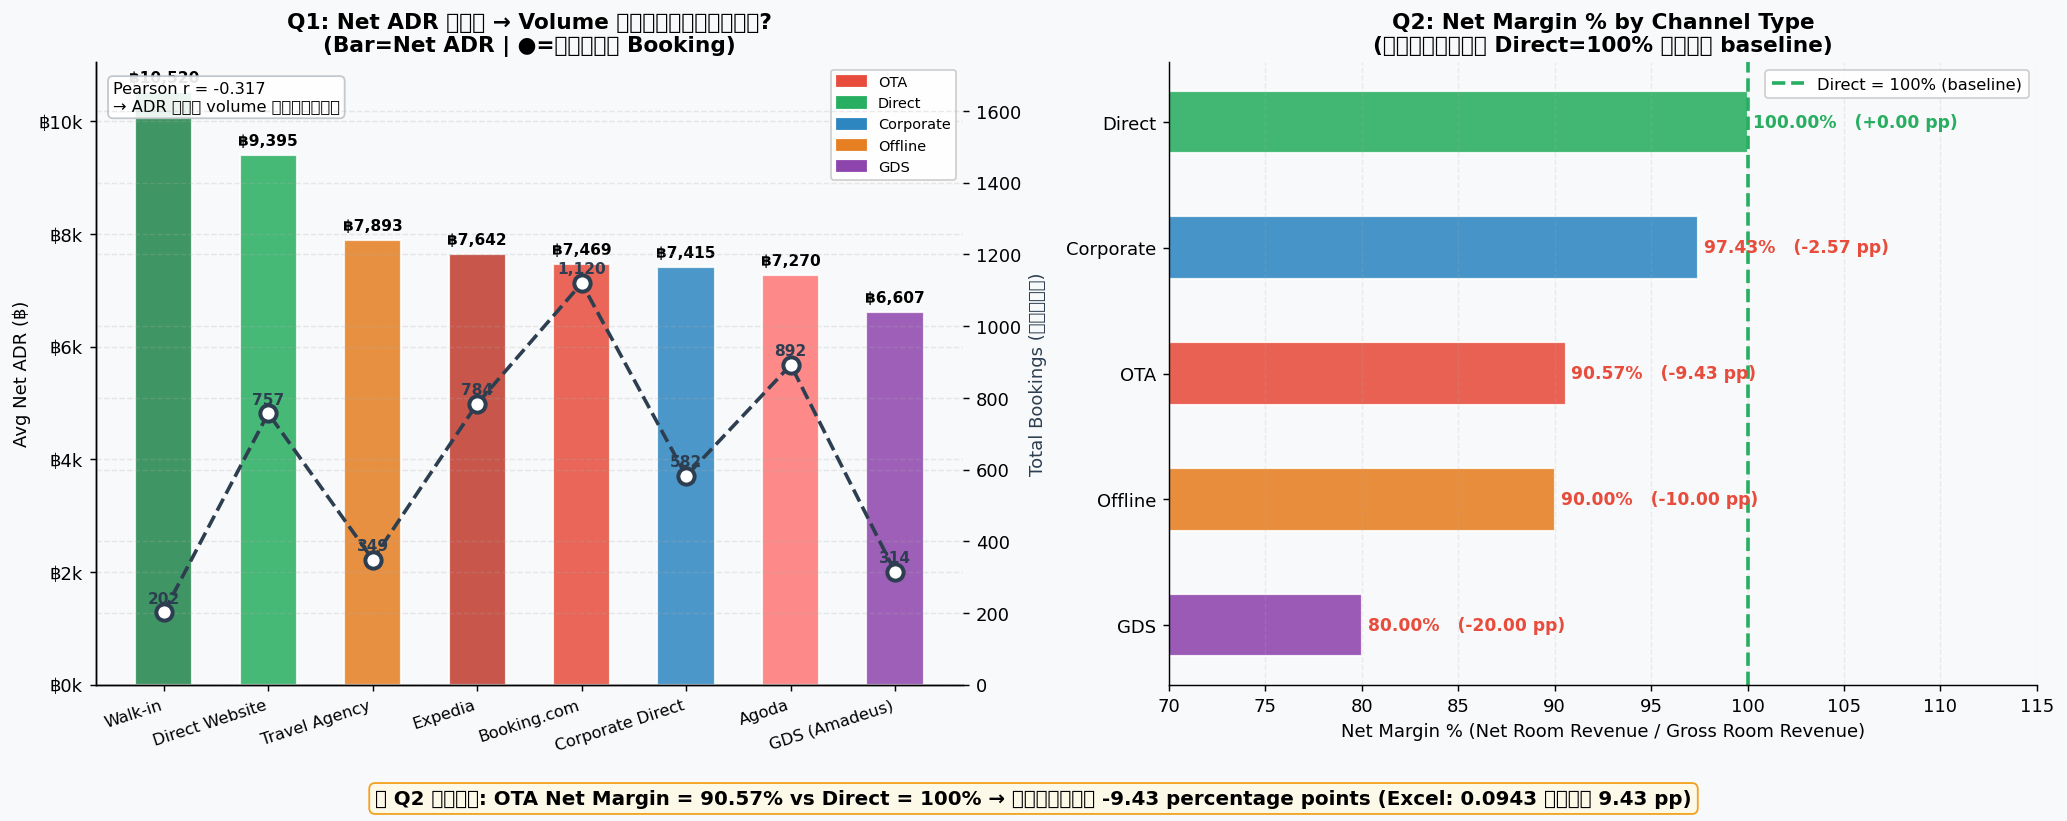

✅ บันทึก: Q1_ADR_Volume_Q2_OTA_Direct_Margin.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)

# ============ Q1: ADR vs Volume ============
ax = axes[0]
ax.set_facecolor(BG)
ch_q1 = ch.sort_values('avg_net_adr', ascending=False).reset_index(drop=True)
labels_q1 = ch_q1['channel_name'].tolist()
colors_q1  = [NAME_COLOR.get(n,'#95A5A6') for n in labels_q1]
x_q1 = np.arange(len(labels_q1))

bars = ax.bar(x_q1, ch_q1['avg_net_adr'], 0.55, color=colors_q1,
              alpha=0.85, edgecolor='white', linewidth=1.2)
for bar, val, t in zip(bars, ch_q1['avg_net_adr'], ch_q1['channel_type']):
    ax.text(bar.get_x()+bar.get_width()/2, val+120,
            f'฿{val:,.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax2 = ax.twinx()
ax2.plot(x_q1, ch_q1['total'], 'o--', color='#2C3E50', lw=2, markersize=9,
         markerfacecolor='white', markeredgewidth=2.2, zorder=5, label='Total Bookings')
for xi, val in zip(x_q1, ch_q1['total']):
    ax2.text(xi, val+18, f'{val:,}', ha='center', va='bottom',
             fontsize=8.5, color='#2C3E50', fontweight='bold')
ax2.set_ylabel('Total Bookings (จำนวน)', fontsize=10, color='#2C3E50')
ax2.set_ylim(0, ch_q1['total'].max() * 1.55)

ax.set_xticks(x_q1)
ax.set_xticklabels(labels_q1, rotation=18, ha='right', fontsize=9)
ax.set_ylabel('Avg Net ADR (฿)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_thb))
ax.set_title('Q1: Net ADR สูง → Volume มากหรือน้อย?\n(Bar=Net ADR | ●=จำนวน Booking)',
             fontsize=12, fontweight='bold')

corr_q1 = np.corrcoef(ch_q1['avg_net_adr'], ch_q1['total'])[0,1]
ax.text(0.02, 0.97, f'Pearson r = {corr_q1:.3f}\n→ ADR สูง volume {"ต่ำ" if corr_q1<0 else "สูง"}กว่า',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', ec='#BDC3C7', alpha=0.9))
legend_t = [mpatches.Patch(color=TYPE_COLOR.get(t,'#95A5A6'), label=t)
            for t in ['OTA','Direct','Corporate','Offline','GDS']]
ax.legend(handles=legend_t, fontsize=8, framealpha=0.9)

# ============ Q2: OTA vs Direct Net Margin ============
ax3 = axes[1]
ax3.set_facecolor(BG)
ax3.grid(axis='x', alpha=0.2)
ax3.grid(axis='y', alpha=0)

# จาก Sheet6: Direct=1.000, Corporate=0.974283, Offline=0.900, OTA=0.905679, GDS=0.800
ct_q2 = ct.sort_values('net_margin_pct', ascending=True)
bar_c  = [TYPE_COLOR.get(t,'#95A5A6') for t in ct_q2['channel_type']]
bars_q2 = ax3.barh(ct_q2['channel_type'], ct_q2['net_margin_pct']*100,
                   color=bar_c, height=0.5, edgecolor='white', linewidth=1.2, alpha=0.88)

direct_m = ct[ct['channel_type']=='Direct']['net_margin_pct'].values[0]
ax3.axvline(direct_m*100, color='#27AE60', lw=2, linestyle='--',
            label=f'Direct = {direct_m:.0%} (baseline)')

for bar, row in zip(bars_q2, ct_q2.itertuples()):
    diff_pp  = row.net_margin_pct - direct_m
    diff_pct = diff_pp / direct_m * 100
    sign = '+' if diff_pct >= 0 else ''
    c_txt = '#27AE60' if diff_pct >= 0 else '#E74C3C'
    ax3.text(row.net_margin_pct*100 + 0.3,
             bar.get_y()+bar.get_height()/2,
             f'{row.net_margin_pct:.2%}   ({sign}{diff_pp*100:.2f} pp)',
             va='center', fontsize=9.5, fontweight='bold', color=c_txt)

ax3.set_xlabel('Net Margin % (Net Room Revenue / Gross Room Revenue)', fontsize=10)
ax3.set_xlim(70, 115)
ax3.set_title('Q2: Net Margin % by Channel Type\n(เทียบกับ Direct=100% เป็น baseline)',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9, framealpha=0.9)

ota_m = ct[ct['channel_type']=='OTA']['net_margin_pct'].values[0]
diff_ota = (ota_m - direct_m)*100
fig.text(0.5, -0.04,
    f'📌 Q2 สรุป: OTA Net Margin = {ota_m:.2%} vs Direct = {direct_m:.0%} → ต่างกัน {diff_ota:.2f} percentage points '
    f'(Excel: 0.0943 หรือ 9.43 pp)',
    ha='center', fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round', fc='#FEF9E7', ec='#F39C12', alpha=0.95))

plt.tight_layout()
save_fig('Q1_ADR_Volume_Q2_OTA_Direct_Margin')

---
## 📊 H2: OTA มีอัตราการยกเลิกสูงกว่า — Stacked Bar Booking Status
**ข้อมูลตรงกับ Sheet4 + H2 sheet ใน Excel**

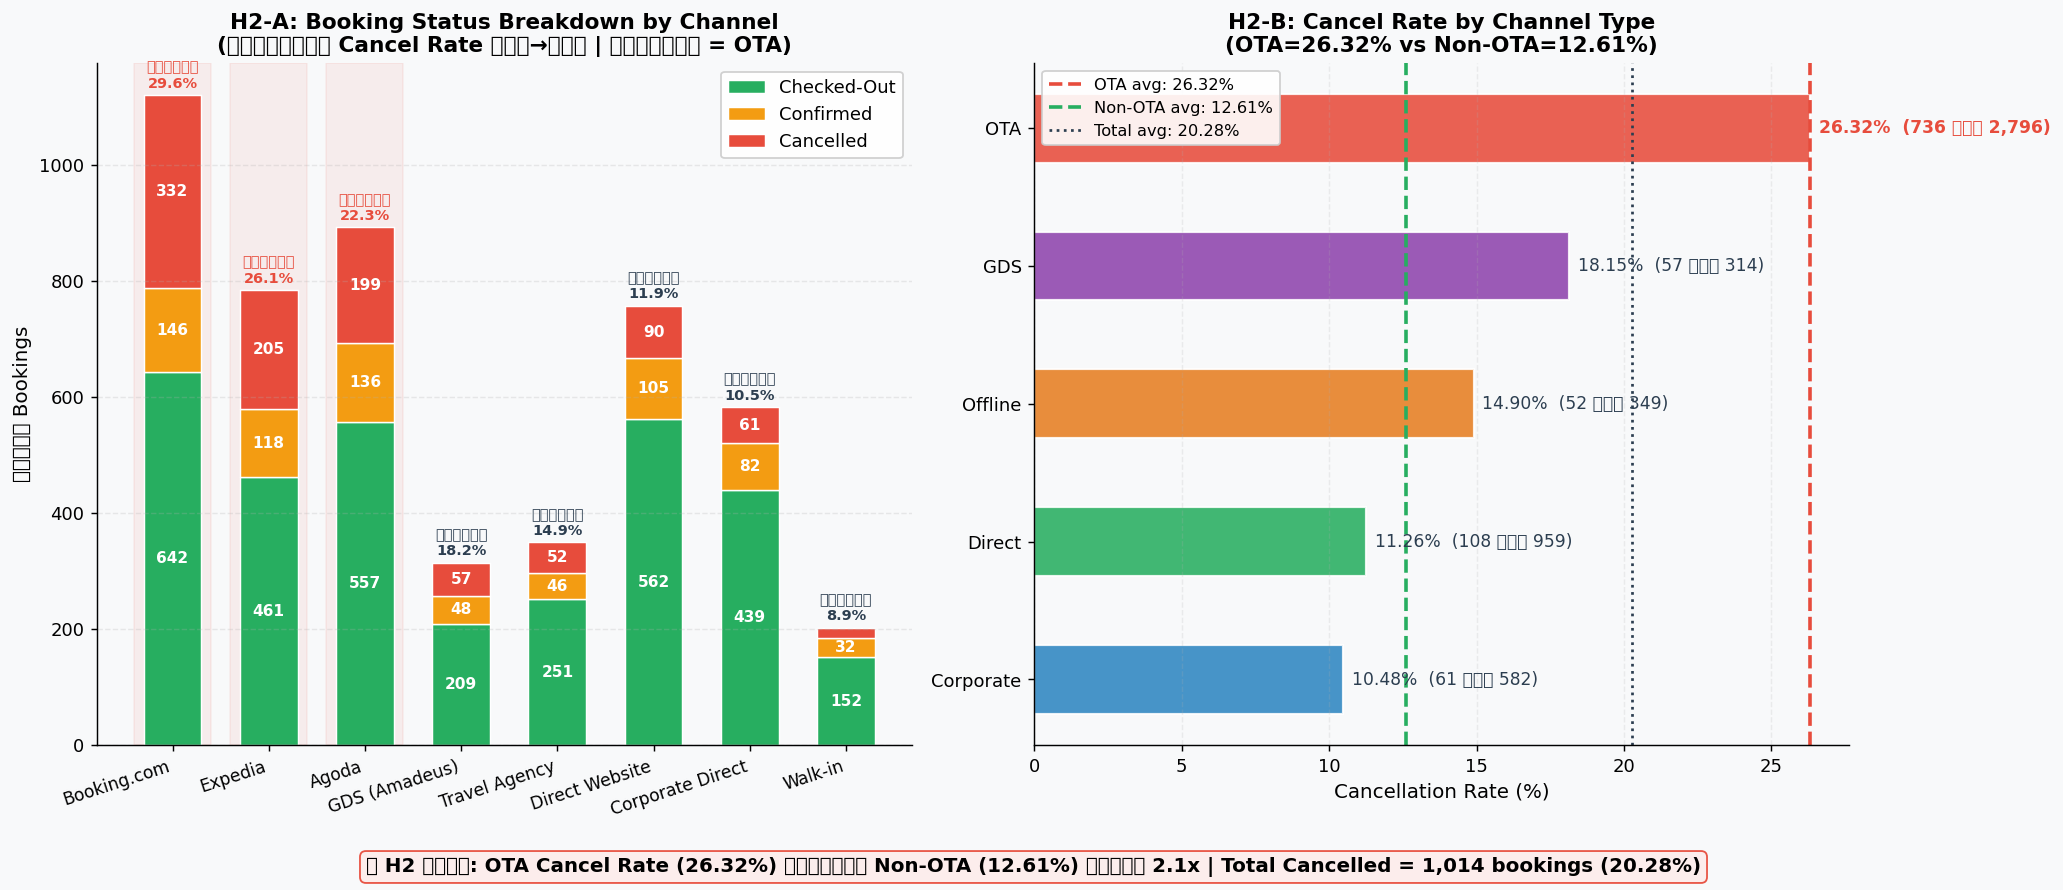

✅ บันทึก: H2_Cancellation_Rate_Analysis.png


In [ ]:
# จาก Sheet4 (Cancelled) + H2 sheet (Checked-Out)
# OTA: Cancelled=736 (Agoda=199, Booking.com=332, Expedia=205)
# Checked-Out: OTA=1660 (Agoda=557, Booking.com=642, Expedia=461)
# Confirmed: Total=713

status_counts = df.groupby(['channel_name','status']).size().unstack(fill_value=0).reset_index()
for col in ['Cancelled','Confirmed','Checked-Out']:
    if col not in status_counts.columns:
        status_counts[col] = 0

status_counts = status_counts.merge(
    ch[['channel_name','channel_type','cancel_rate','net_margin_pct']], on='channel_name')
status_counts = status_counts.sort_values('cancel_rate', ascending=False).reset_index(drop=True)
status_counts['total'] = status_counts[['Cancelled','Confirmed','Checked-Out']].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.patch.set_facecolor(BG)

# ===== LEFT: Stacked Bar =====
ax = axes[0]
ax.set_facecolor(BG)
labels_h2 = status_counts['channel_name'].tolist()
x = np.arange(len(labels_h2))
w = 0.6
STATUS_C = {'Checked-Out':'#27AE60', 'Confirmed':'#F39C12', 'Cancelled':'#E74C3C'}

bottom = np.zeros(len(labels_h2))
for s in ['Checked-Out','Confirmed','Cancelled']:
    vals = status_counts[s].values.astype(float)
    bars = ax.bar(x, vals, w, bottom=bottom, color=STATUS_C[s],
                  label=s, edgecolor='white', linewidth=0.8)
    for xi, (b, v) in enumerate(zip(bottom, vals)):
        if v >= 30:
            ax.text(xi, b + v/2, f'{int(v)}', ha='center', va='center',
                    fontsize=8.5, color='white', fontweight='bold')
    bottom += vals

# Cancel rate label บนยอด
for xi, (tot, cr, ctype) in enumerate(zip(status_counts['total'],
                                           status_counts['cancel_rate'],
                                           status_counts['channel_type'])):
    c_lbl = '#E74C3C' if ctype=='OTA' else '#2C3E50'
    ax.text(xi, tot + 8, f'ยกเลิก\n{cr:.1%}',
            ha='center', va='bottom', fontsize=8, fontweight='bold', color=c_lbl)

# OTA shade
for xi, ctype in enumerate(status_counts['channel_type']):
    if ctype == 'OTA':
        ax.axvspan(xi-0.4, xi+0.4, alpha=0.07, color='#E74C3C', zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(labels_h2, rotation=18, ha='right', fontsize=9.5)
ax.set_ylabel('จำนวน Bookings', fontsize=11)
ax.set_title('H2-A: Booking Status Breakdown by Channel\n(เรียงตาม Cancel Rate สูง→ต่ำ | พื้นแดง = OTA)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)

# ===== RIGHT: Cancel Rate Bar (OTA vs Non-OTA) =====
ax2 = axes[1]
ax2.set_facecolor(BG)
ax2.grid(axis='x', alpha=0.2); ax2.grid(axis='y', alpha=0)

ct_h2 = ct.sort_values('cancel_rate', ascending=True)
bar_c2 = [TYPE_COLOR.get(t,'#95A5A6') for t in ct_h2['channel_type']]
bars2 = ax2.barh(ct_h2['channel_type'], ct_h2['cancel_rate']*100,
                 color=bar_c2, height=0.5, edgecolor='white', linewidth=1.2, alpha=0.88)

# Reference lines จากข้อมูลจริง
ota_cr   = df[df['channel_type']=='OTA']['Cancelled Flag'].mean()    # 0.2632
nota_cr  = df[df['channel_type']!='OTA']['Cancelled Flag'].mean()   # 0.1261
total_cr = df['Cancelled Flag'].mean()                               # 0.2028

ax2.axvline(ota_cr*100,   color='#E74C3C', lw=2,   linestyle='--', label=f'OTA avg: {ota_cr:.2%}')
ax2.axvline(nota_cr*100,  color='#27AE60', lw=2,   linestyle='--', label=f'Non-OTA avg: {nota_cr:.2%}')
ax2.axvline(total_cr*100, color='#2C3E50', lw=1.5, linestyle=':',  label=f'Total avg: {total_cr:.2%}')

for bar, row in zip(bars2, ct_h2.itertuples()):
    is_ota = row.channel_type == 'OTA'
    ax2.text(row.cancel_rate*100 + 0.3,
             bar.get_y()+bar.get_height()/2,
             f'{row.cancel_rate:.2%}  ({int(row.cancelled):,} จาก {int(row.total):,})',
             va='center', fontsize=9.5,
             fontweight='bold' if is_ota else 'normal',
             color='#E74C3C' if is_ota else '#2C3E50')

ax2.set_xlabel('Cancellation Rate (%)', fontsize=11)
ax2.set_title('H2-B: Cancel Rate by Channel Type\n(OTA=26.32% vs Non-OTA=12.61%)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, framealpha=0.9)

fig.text(0.5, -0.04,
    f'📌 H2 สรุป: OTA Cancel Rate ({ota_cr:.2%}) สูงกว่า Non-OTA ({nota_cr:.2%}) '
    f'เกือบ {ota_cr/nota_cr:.1f}x | Total Cancelled = {int(df["Cancelled Flag"].sum()):,} bookings ({total_cr:.2%})',
    ha='center', fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round', fc='#FDEDEC', ec='#E74C3C', alpha=0.95))

plt.tight_layout()
save_fig('H2_Cancellation_Rate_Analysis')

---
## ❓ Q3: Cancellation ส่งผลต่อ Net Revenue มากแค่ไหน?
**ข้อมูลตรงกับ H2 sheet + Sheet4 ใน Excel**

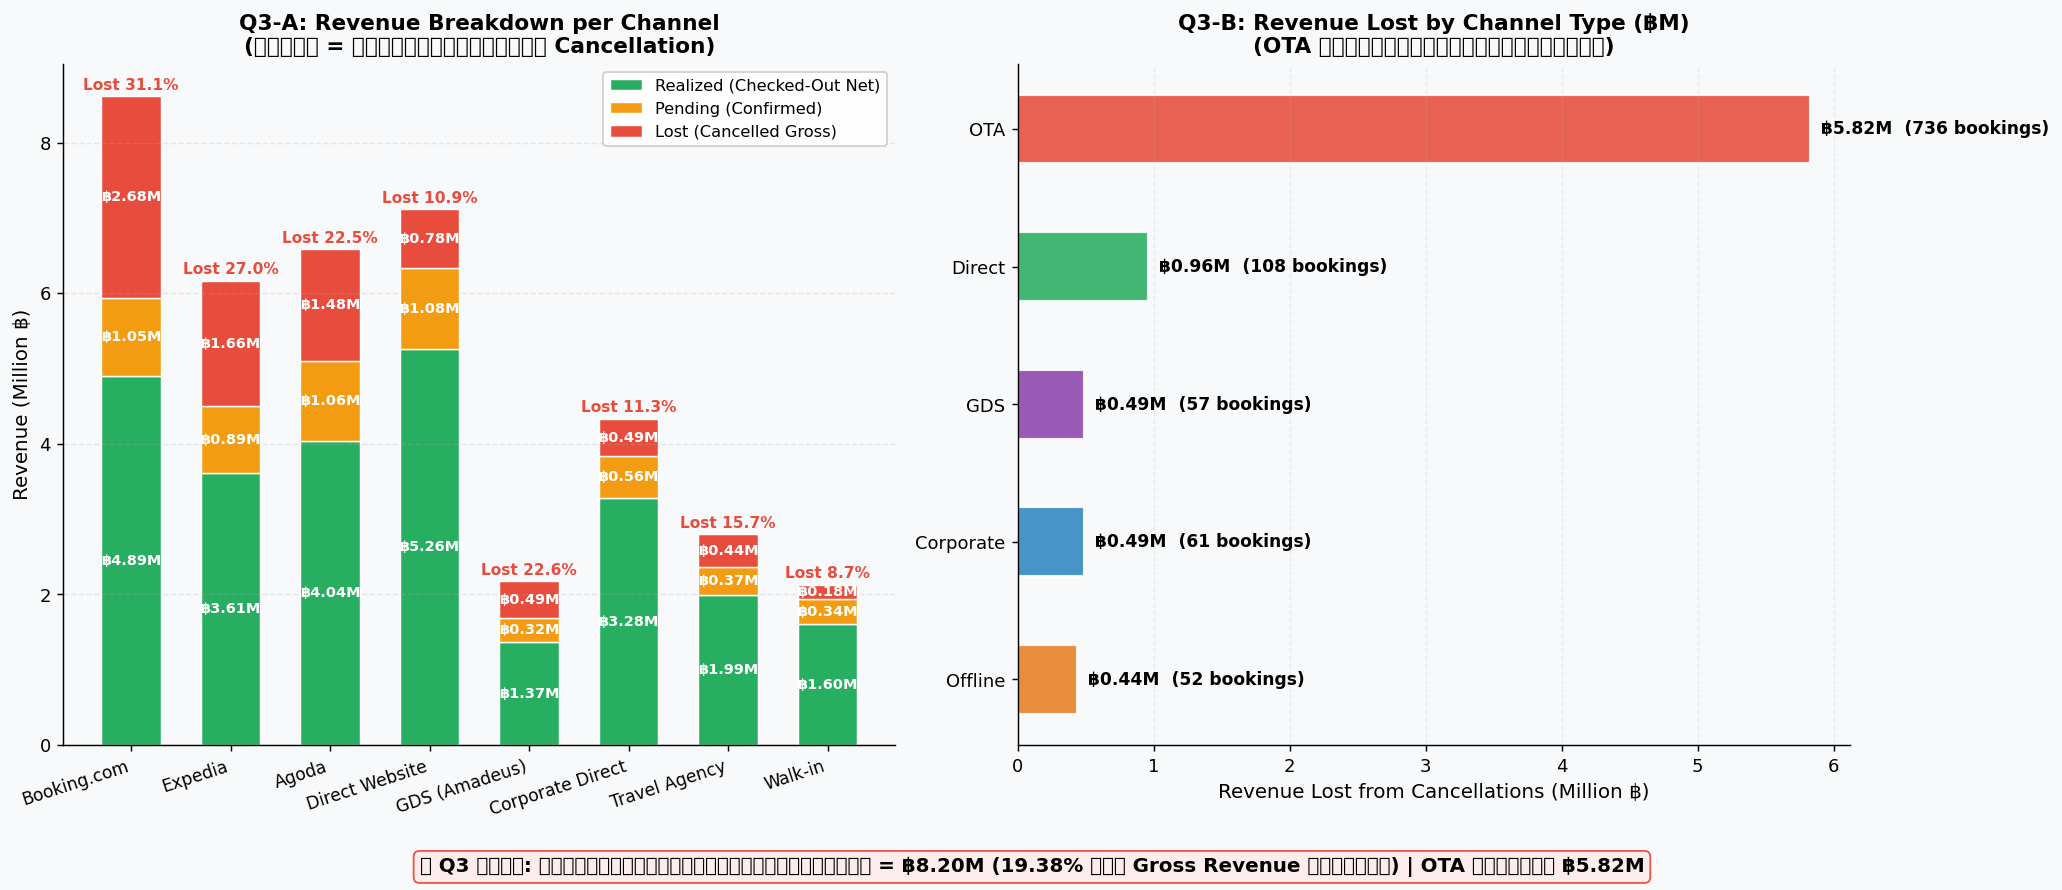

✅ บันทึก: Q3_Revenue_Lost_Cancellation.png


In [ ]:
# Net_revenue ของ Cancelled = 0 (ตามข้อมูลในไฟล์ Excel)
# Realized revenue = Net_revenue ของ Checked-Out bookings
# จาก H2 sheet: OTA Checked-Out net rev = 12,548,606.38, Gross = 13,875,246.49

rev_ch = df.groupby(['channel_name','channel_type']).apply(lambda g: pd.Series({
    'realized_net' : g[g['Checked-Out Flag']==1]['net_room_revenue'].sum(),
    'realized_gross': g[g['Checked-Out Flag']==1]['gross_room_revenue'].sum(),
    'lost_gross'   : g[g['Cancelled Flag']==1]['gross_room_revenue'].sum(),  # รายได้ที่หายไป
    'pending_net'  : g[(g['Checked-Out Flag']==0)&(g['Cancelled Flag']==0)]['net_room_revenue'].sum(),
})).reset_index()
rev_ch['potential'] = rev_ch['realized_net'] + rev_ch['lost_gross'] + rev_ch['pending_net']
rev_ch['lost_pct']  = rev_ch['lost_gross'] / rev_ch['potential']
rev_ch = rev_ch.sort_values('lost_gross', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.patch.set_facecolor(BG)

# ===== LEFT: Stacked Bar — Revenue breakdown =====
ax = axes[0]
ax.set_facecolor(BG)
labels_r = rev_ch['channel_name'].tolist()
x_r = np.arange(len(labels_r)); w_r = 0.6

REV_C = {'realized_net':'#27AE60', 'pending_net':'#F39C12', 'lost_gross':'#E74C3C'}
REV_L = {'realized_net':'Realized (Checked-Out Net)', 'pending_net':'Pending (Confirmed)',
          'lost_gross':'Lost (Cancelled Gross)'}
bottom_r = np.zeros(len(labels_r))
for col in ['realized_net','pending_net','lost_gross']:
    vals = rev_ch[col].values / 1e6
    bars = ax.bar(x_r, vals, w_r, bottom=bottom_r,
                  color=REV_C[col], label=REV_L[col], edgecolor='white', linewidth=0.8)
    for xi, (b, v) in enumerate(zip(bottom_r, vals)):
        if v > 0.15:
            ax.text(xi, b+v/2, f'฿{v:.2f}M', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom_r += vals

for xi, row in enumerate(rev_ch.itertuples()):
    ax.text(xi, row.potential/1e6 + 0.05,
            f'Lost {row.lost_pct:.1%}',
            ha='center', va='bottom', fontsize=8.5, color='#E74C3C', fontweight='bold')

ax.set_xticks(x_r)
ax.set_xticklabels(labels_r, rotation=18, ha='right', fontsize=9.5)
ax.set_ylabel('Revenue (Million ฿)', fontsize=11)
ax.set_title('Q3-A: Revenue Breakdown per Channel\n(สีแดง = รายได้ที่หายจาก Cancellation)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9, loc='upper right')

# ===== RIGHT: Revenue Lost ฿ by Channel Type =====
ax2 = axes[1]
ax2.set_facecolor(BG)
ax2.grid(axis='x', alpha=0.2); ax2.grid(axis='y', alpha=0)

rev_ct = df[df['Cancelled Flag']==1].groupby('channel_type').agg(
    lost_gross  = ('gross_room_revenue','sum'),
    n_cancelled = ('booking_id','count'),
).reset_index().sort_values('lost_gross')
bar_c3 = [TYPE_COLOR.get(t,'#95A5A6') for t in rev_ct['channel_type']]
bars3  = ax2.barh(rev_ct['channel_type'], rev_ct['lost_gross']/1e6,
                  color=bar_c3, height=0.5, edgecolor='white', linewidth=1.2, alpha=0.88)

for bar, row in zip(bars3, rev_ct.itertuples()):
    ax2.text(row.lost_gross/1e6 + 0.08,
             bar.get_y()+bar.get_height()/2,
             f'฿{row.lost_gross/1e6:.2f}M  ({int(row.n_cancelled):,} bookings)',
             va='center', fontsize=9.5, fontweight='bold')

ax2.set_xlabel('Revenue Lost from Cancellations (Million ฿)', fontsize=11)
ax2.set_title('Q3-B: Revenue Lost by Channel Type (฿M)\n(OTA สูญเสียรายได้มากที่สุด)', fontsize=12, fontweight='bold')

total_lost  = df[df['Cancelled Flag']==1]['gross_room_revenue'].sum()
total_gross = df['gross_room_revenue'].sum()
fig.text(0.5, -0.04,
    f'📌 Q3 สรุป: รายได้หายจากการยกเลิกทั้งหมด = ฿{total_lost/1e6:.2f}M '
    f'({total_lost/total_gross:.2%} ของ Gross Revenue ทั้งหมด) | '
    f'OTA สูญเสีย ฿{rev_ct[rev_ct["channel_type"]=="OTA"]["lost_gross"].sum()/1e6:.2f}M',
    ha='center', fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round', fc='#FDEDEC', ec='#E74C3C', alpha=0.95))

plt.tight_layout()
save_fig('Q3_Revenue_Lost_Cancellation')

---
## 📊 H3 + ❓ Q4: Commission สูง → Net ADR ต่ำจริงหรือไม่?
**กราฟ: Bar ค่า Commission Rate + Net ADR เทียบคู่ + Heatmap Correlation**

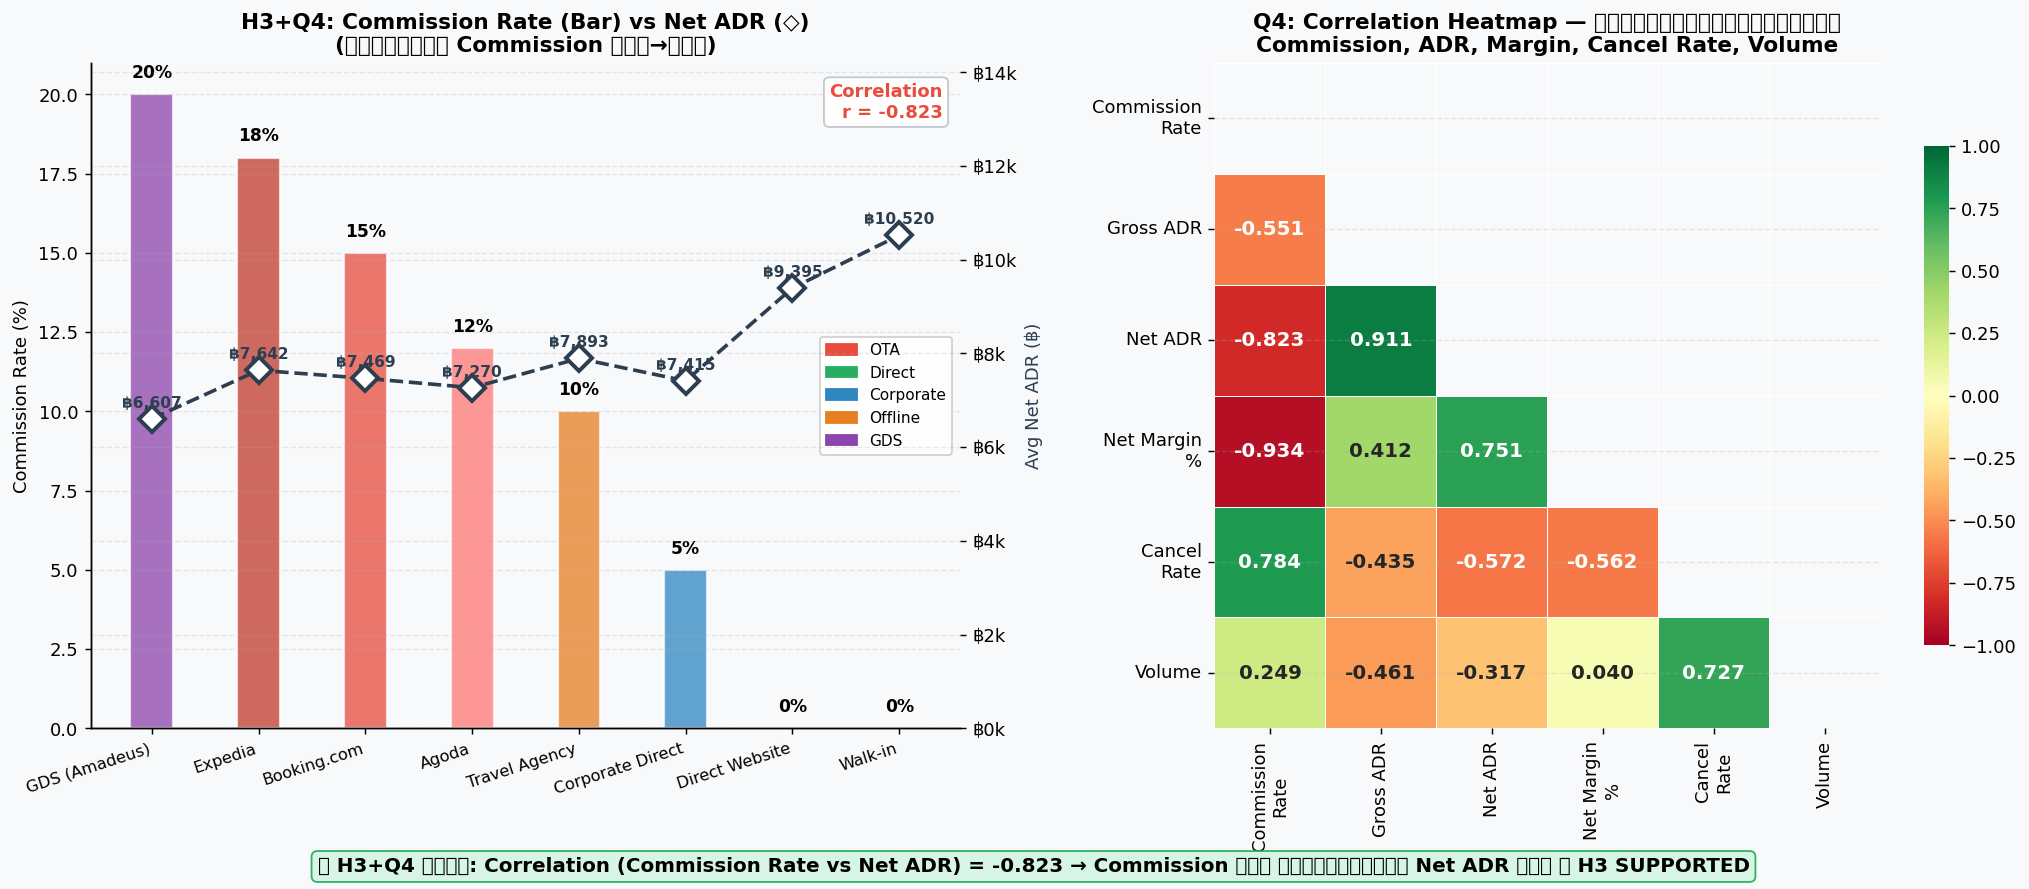

✅ บันทึก: H3_Q4_Commission_vs_NetADR.png


In [ ]:
# จาก dim_channels: GDS=20%, Expedia=18%, Booking.com=15%, Agoda=12%,
#                   Travel Agency=10%, Corporate=5%, Direct=0%
ch_h3 = ch.sort_values('comm_rate', ascending=False).reset_index(drop=True)
labels_h3 = ch_h3['channel_name'].tolist()
x_h3 = np.arange(len(labels_h3))
colors_h3 = [NAME_COLOR.get(n,'#95A5A6') for n in labels_h3]

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.patch.set_facecolor(BG)

# ===== LEFT: Commission Rate + Net ADR Dual Axis =====
ax = axes[0]
ax.set_facecolor(BG)

# Commission Rate bars
bars_c = ax.bar(x_h3, ch_h3['comm_rate']*100, 0.4,
                color=colors_h3, alpha=0.75, edgecolor='white', linewidth=1.2,
                label='Commission Rate (%)')
for bar, val in zip(bars_c, ch_h3['comm_rate']):
    ax.text(bar.get_x()+bar.get_width()/2, val*100+0.4,
            f'{val:.0%}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# Net ADR on secondary axis
ax2 = ax.twinx()
ax2.plot(x_h3, ch_h3['avg_net_adr'], 'D--', color='#2C3E50', lw=2, markersize=10,
         markerfacecolor='white', markeredgewidth=2.2, zorder=5, label='Avg Net ADR (฿)')
for xi, val in zip(x_h3, ch_h3['avg_net_adr']):
    ax2.text(xi, val+180, f'฿{val:,.0f}',
             ha='center', va='bottom', fontsize=8.5, color='#2C3E50', fontweight='bold')
ax2.set_ylabel('Avg Net ADR (฿)', fontsize=10, color='#2C3E50')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_thb))
ax2.set_ylim(0, ch_h3['avg_net_adr'].max() * 1.35)

ax.set_xticks(x_h3)
ax.set_xticklabels(labels_h3, rotation=18, ha='right', fontsize=9)
ax.set_ylabel('Commission Rate (%)', fontsize=10)
ax.set_title('H3+Q4: Commission Rate (Bar) vs Net ADR (◇)\n(เรียงตาม Commission สูง→ต่ำ)',
             fontsize=12, fontweight='bold')
legend_t = [mpatches.Patch(color=TYPE_COLOR.get(t,'#95A5A6'), label=t)
            for t in ['OTA','Direct','Corporate','Offline','GDS']]
ax.legend(handles=legend_t, fontsize=8.5, framealpha=0.9)
corr_h3 = ch_h3['comm_rate'].corr(ch_h3['avg_net_adr'])
ax.text(0.98, 0.97, f'Correlation\nr = {corr_h3:.3f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=10, fontweight='bold',
        color='#E74C3C' if corr_h3 < 0 else '#27AE60',
        bbox=dict(boxstyle='round', fc='white', ec='#BDC3C7', alpha=0.9))

# ===== RIGHT: Correlation Heatmap =====
ax3 = axes[1]
ax3.set_facecolor(BG)

hm_data = ch[['comm_rate','avg_gross_adr','avg_net_adr','net_margin_pct','cancel_rate','total']].copy()
hm_data.columns = ['Commission\nRate','Gross ADR','Net ADR','Net Margin\n%','Cancel\nRate','Volume']
corr_m = hm_data.corr()

mask = np.triu(np.ones_like(corr_m, dtype=bool))
sns.heatmap(
    corr_m, mask=mask, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size':11, 'weight':'bold'},
    ax=ax3, square=True, cbar_kws={'shrink':0.75}
)
ax3.set_title('Q4: Correlation Heatmap — ความสัมพันธ์ระหว่าง\nCommission, ADR, Margin, Cancel Rate, Volume',
              fontsize=12, fontweight='bold')

fig.text(0.5, -0.04,
    f'📌 H3+Q4 สรุป: Correlation (Commission Rate vs Net ADR) = {corr_h3:.3f} '
    f'→ {"Commission สูง สัมพันธ์กับ Net ADR ต่ำ ✅ H3 SUPPORTED" if corr_h3 < -0.3 else "ความสัมพันธ์ไม่ชัดเจน ⚠️"}',
    ha='center', fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round',
              fc='#D5F5E3' if corr_h3 < -0.3 else '#FEF9E7',
              ec='#27AE60' if corr_h3 < -0.3 else '#F39C12', alpha=0.95))

plt.tight_layout()
save_fig('H3_Q4_Commission_vs_NetADR')

---
## ❓ Q5: Cancellation ส่งผลต่อ Net Margin ของ booking ที่สำเร็จจริงแค่ไหน?
**ข้อมูลตรงกับ H2 sheet แถว 87-95 (Average of netmargin by Status)**

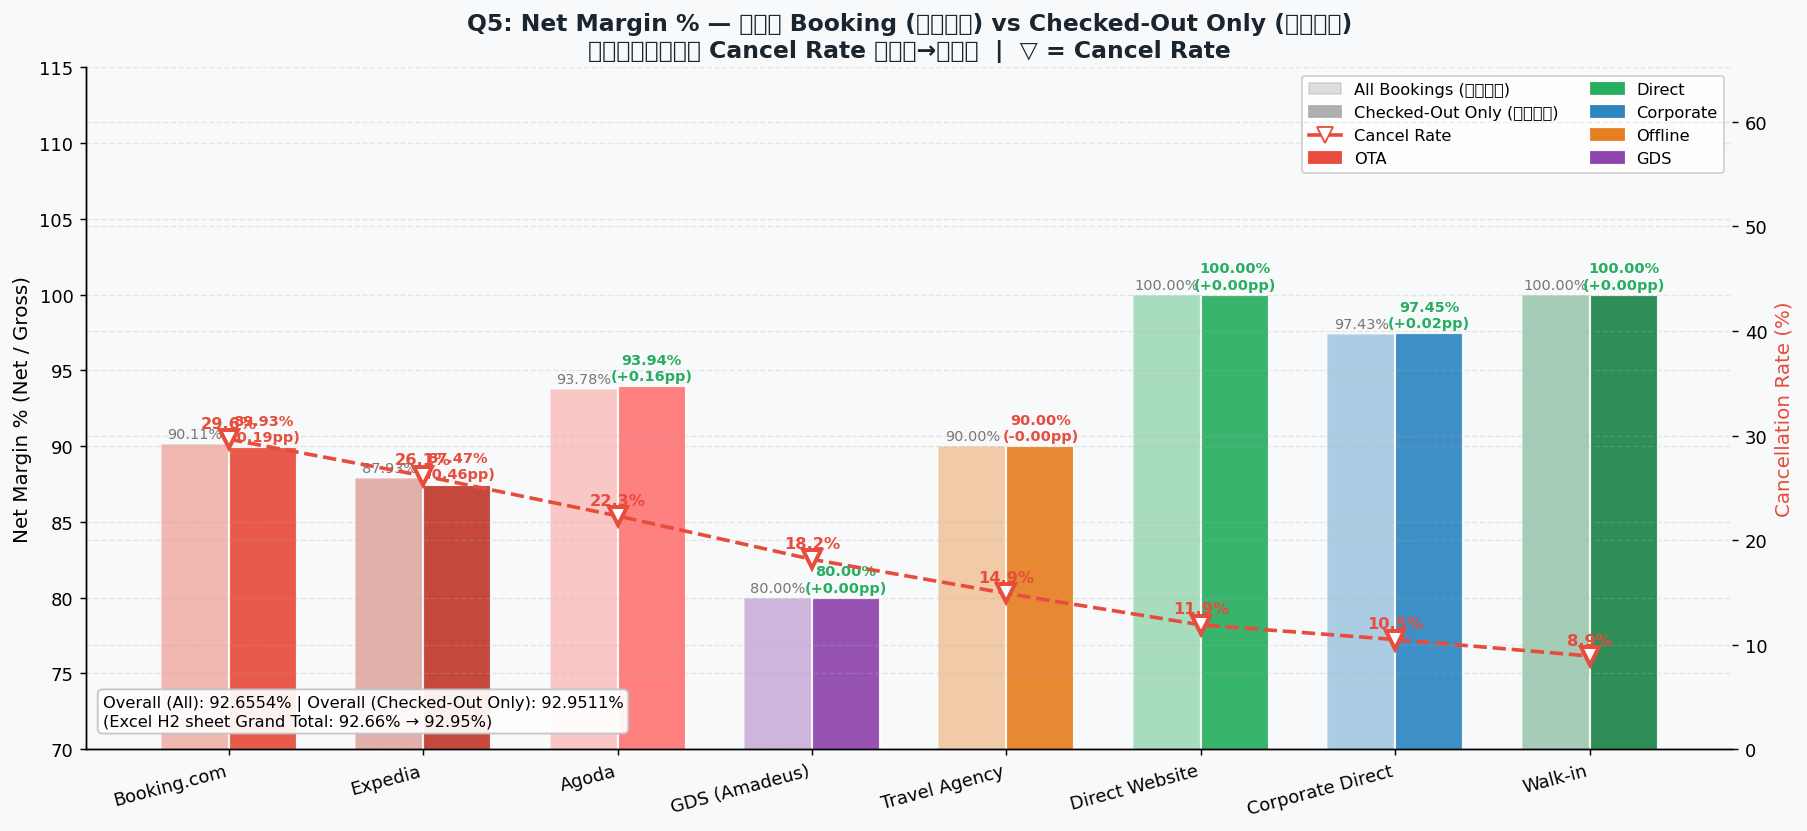

✅ บันทึก: Q5_Cancel_Impact_on_Margin.png


In [ ]:
# จาก H2 sheet (Excel) — Average of netmargin (= net/gross) by Channel และ Status:
# Agoda:    Cancelled=0.9326, Checked-Out=0.9394, Confirmed=0.9386, Total=0.9378
# Booking.com: Cancelled=0.9061, CO=0.8993, Conf=0.8985, Total=0.9011
# Expedia:  Cancelled=0.8949, CO=0.8747, Conf=0.8723, Total=0.8793
# Direct Website: All=1.0000
# Walk-in:  All=1.0000

# คำนวณจากข้อมูลจริง (ตรงกับ Pivot)
margin_by_status = df.groupby(['channel_name','status']).apply(
    lambda g: g['net_room_revenue'].sum() / g['gross_room_revenue'].sum()
).reset_index(name='net_margin_pct')

# Overall margin per channel (all vs checked-out only)
ch_q5 = ch.sort_values('cancel_rate', ascending=False).reset_index(drop=True)
labels_q5 = ch_q5['channel_name'].tolist()
colors_q5  = [NAME_COLOR.get(n,'#95A5A6') for n in labels_q5]
x_q5 = np.arange(len(labels_q5)); w_q5 = 0.35

fig, ax = plt.subplots(figsize=(14, 6.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# All bookings margin (อ่อน)
b1 = ax.bar(x_q5 - w_q5/2, ch_q5['net_margin_pct']*100, w_q5,
            color=colors_q5, alpha=0.38, edgecolor='white', linewidth=1.2,
            label='Net Margin % — ทุก Booking')
# Checked-Out only margin (เข้ม)
b2 = ax.bar(x_q5 + w_q5/2, ch_q5['margin_co']*100, w_q5,
            color=colors_q5, alpha=0.92, edgecolor='white', linewidth=1.2,
            label='Net Margin % — Checked-Out เท่านั้น')

for bar, val in zip(b1, ch_q5['net_margin_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, val*100+0.2,
            f'{val:.2%}', ha='center', va='bottom', fontsize=8, color='#777')
for bar, val_all, val_co, t in zip(b2, ch_q5['net_margin_pct'],
                                    ch_q5['margin_co'], ch_q5['channel_type']):
    diff = (val_co - val_all)*100
    sign = '+' if diff >= 0 else ''
    c_txt = '#27AE60' if diff >= 0 else '#E74C3C'
    ax.text(bar.get_x()+bar.get_width()/2, val_co*100+0.2,
            f'{val_co:.2%}\n({sign}{diff:.2f}pp)',
            ha='center', va='bottom', fontsize=8, fontweight='bold', color=c_txt)

# Cancel Rate secondary axis
ax2 = ax.twinx()
ax2.plot(x_q5, ch_q5['cancel_rate']*100, 'v--', color='#E74C3C', lw=2, markersize=10,
         markerfacecolor='white', markeredgewidth=2.2, zorder=5, label='Cancel Rate')
for xi, val in zip(x_q5, ch_q5['cancel_rate']):
    ax2.text(xi, val*100+0.8, f'{val:.1%}', ha='center', va='bottom',
             fontsize=9, color='#E74C3C', fontweight='bold')
ax2.set_ylabel('Cancellation Rate (%)', fontsize=11, color='#E74C3C')
ax2.set_ylim(0, ch_q5['cancel_rate'].max()*100 * 2.2)

ax.set_xticks(x_q5)
ax.set_xticklabels(labels_q5, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Net Margin % (Net / Gross)', fontsize=11)
ax.set_ylim(70, 115)
ax.set_title(
    'Q5: Net Margin % — ทุก Booking (อ่อน) vs Checked-Out Only (เข้ม)\n'
    'เรียงตาม Cancel Rate สูง→ต่ำ  |  ▽ = Cancel Rate',
    fontsize=13, fontweight='bold', color='#1A252F')

legend_base = [mpatches.Patch(color='#AAAAAA', alpha=0.38, label='All Bookings (อ่อน)'),
               mpatches.Patch(color='#AAAAAA', alpha=0.92, label='Checked-Out Only (เข้ม)'),
               plt.Line2D([0],[0], marker='v', color='#E74C3C', lw=2, markersize=9,
                          markerfacecolor='white', label='Cancel Rate')]
legend_type = [mpatches.Patch(color=TYPE_COLOR.get(t,'#95A5A6'), label=t)
               for t in ['OTA','Direct','Corporate','Offline','GDS']]
ax.legend(handles=legend_base+legend_type, fontsize=9, ncol=2, framealpha=0.9)

# ข้อสรุปจาก H2 Excel sheet
overall_all = df['net_room_revenue'].sum()/df['gross_room_revenue'].sum()
overall_co  = (df[df['Checked-Out Flag']==1]['net_room_revenue'].sum() /
               df[df['Checked-Out Flag']==1]['gross_room_revenue'].sum())
ax.text(0.01, 0.03,
    f'Overall (All): {overall_all:.4%} | Overall (Checked-Out Only): {overall_co:.4%}\n'
    f'(Excel H2 sheet Grand Total: 92.66% → 92.95%)',
    transform=ax.transAxes, va='bottom', fontsize=9,
    bbox=dict(boxstyle='round', fc='white', ec='#BDC3C7', alpha=0.92))

plt.tight_layout()
save_fig('Q5_Cancel_Impact_on_Margin')

---
## ❓ Q6: ถ้าตัด OTA ออก → รายได้หายเท่าไร vs Margin ดีขึ้นเท่าไร?
**กราฟ: Scenario Donut + Before/After Bar Comparison**

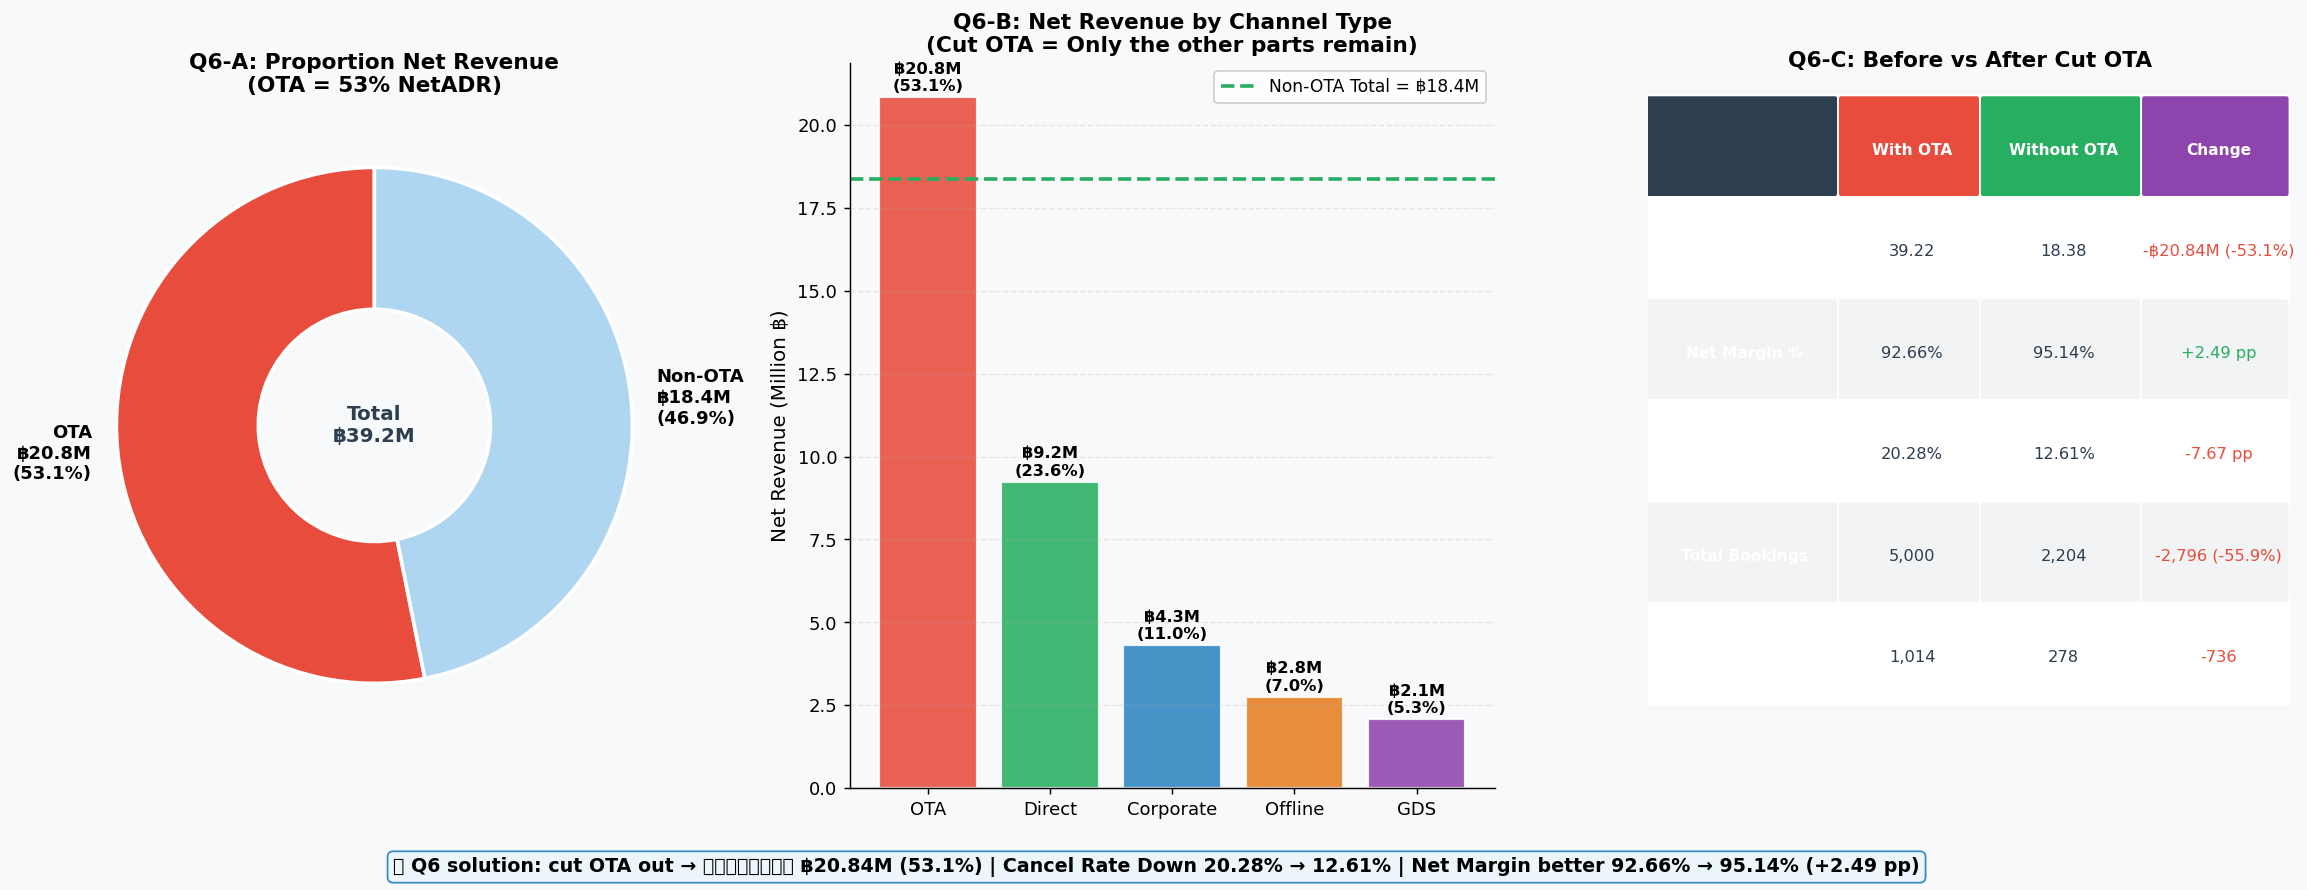

✅ บันทึก: Q6_Remove_OTA_Scenario.png


In [ ]:
# ตัวเลขจากข้อมูล Excel:
# OTA total net rev = 20,841,285.55 (53.13% ของ total)
# Non-OTA total net rev = 18,381,953.51 (46.87%)
# OTA cancel rate = 26.32%, Non-OTA = 12.61%
# OTA Net Margin = 90.57%, Non-OTA = 95.14%

ota_df   = df[df['channel_type']=='OTA']
nota_df  = df[df['channel_type']!='OTA']

ota_net  = ota_df['net_room_revenue'].sum()   # 20,841,285.55
nota_net = nota_df['net_room_revenue'].sum()  # 18,381,953.51
total_net= df['net_room_revenue'].sum()       # 39,223,239.06

ota_margin  = ota_df['net_room_revenue'].sum()  / ota_df['gross_room_revenue'].sum()
nota_margin = nota_df['net_room_revenue'].sum() / nota_df['gross_room_revenue'].sum()
total_margin= total_net / df['gross_room_revenue'].sum()

ota_cr  = ota_df['Cancelled Flag'].mean()
nota_cr = nota_df['Cancelled Flag'].mean()
total_cr= df['Cancelled Flag'].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
fig.patch.set_facecolor(BG)

# ===== LEFT: Revenue Share Donut =====
ax = axes[0]
ax.set_facecolor(BG)
donut_vals = [ota_net, nota_net]
donut_lbls = [f'OTA\n฿{ota_net/1e6:.1f}M\n({ota_net/total_net:.1%})',
              f'Non-OTA\n฿{nota_net/1e6:.1f}M\n({nota_net/total_net:.1%})']
donut_c = ['#E74C3C', '#AED6F1']
wedges, texts = ax.pie(
    donut_vals, labels=donut_lbls, colors=donut_c,
    startangle=90, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops={'fontsize':10,'fontweight':'bold'}
)
ax.text(0, 0, f'Total\n฿{total_net/1e6:.1f}M',
        ha='center', va='center', fontsize=11, fontweight='bold', color='#2C3E50')
ax.set_title('Q6-A: Proportion Net Revenue\n(OTA = 53% NetADR)', fontsize=12, fontweight='bold')

# ===== MIDDLE: Before vs After — Net Revenue by Channel Type =====
ax2 = axes[1]
ax2.set_facecolor(BG)

rev_types = ct.sort_values('sum_net', ascending=False)
bar_c_ct  = [TYPE_COLOR.get(t,'#95A5A6') for t in rev_types['channel_type']]
bars_ct   = ax2.bar(rev_types['channel_type'], rev_types['sum_net']/1e6,
                    color=bar_c_ct, edgecolor='white', linewidth=1.2, alpha=0.88)

for bar, row in zip(bars_ct, rev_types.itertuples()):
    share = row.sum_net / total_net
    ax2.text(bar.get_x()+bar.get_width()/2, row.sum_net/1e6 + 0.1,
             f'฿{row.sum_net/1e6:.1f}M\n({share:.1%})',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.axhline(nota_net/1e6, color='#27AE60', lw=2, linestyle='--',
            label=f'Non-OTA Total = ฿{nota_net/1e6:.1f}M')
ax2.set_ylabel('Net Revenue (Million ฿)', fontsize=11)
ax2.set_title('Q6-B: Net Revenue by Channel Type\n(Cut OTA = Only the other parts remain)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9.5, framealpha=0.9)

# ===== RIGHT: Before vs After KPI Comparison =====
ax3 = axes[2]
ax3.set_facecolor(BG)
ax3.axis('off')

table_data = [
    ['', 'With OTA', 'Without OTA', 'Change'],
    ['Net Revenue (฿M)', f'{total_net/1e6:.2f}', f'{nota_net/1e6:.2f}',
     f'-฿{ota_net/1e6:.2f}M ({-ota_net/total_net:.1%})'],
    ['Net Margin %', f'{total_margin:.2%}', f'{nota_margin:.2%}',
     f'+{(nota_margin-total_margin)*100:.2f} pp'],
    ['Cancel Rate', f'{total_cr:.2%}', f'{nota_cr:.2%}',
     f'-{(total_cr-nota_cr)*100:.2f} pp'],
    ['Total Bookings', f'{len(df):,}', f'{len(nota_df):,}',
     f'-{len(ota_df):,} ({-len(ota_df)/len(df):.1%})'],
    ['Cancelled Bookings', f'{int(df["Cancelled Flag"].sum()):,}',
     f'{int(nota_df["Cancelled Flag"].sum()):,}',
     f'-{int(ota_df["Cancelled Flag"].sum()):,}'],
]

col_w = [0.30, 0.22, 0.25, 0.23]
row_h = 0.14
col_colors = ['#2C3E50','#E74C3C','#27AE60','#8E44AD']

for ri, row in enumerate(table_data):
    y_pos = 0.95 - ri * row_h
    xpos = 0.0
    for ci, (cell, cw) in enumerate(zip(row, col_w)):
        is_header = (ri == 0 or ci == 0)
        bg_c = col_colors[ci] if ri == 0 else ('#F2F3F4' if ri % 2 == 0 else 'white')
        rect = mpatches.FancyBboxPatch(
            (xpos, y_pos-row_h+0.01), cw-0.01, row_h-0.01,
            boxstyle='round,pad=0.005', transform=ax3.transAxes,
            facecolor=bg_c, edgecolor='white', linewidth=1)
        ax3.add_patch(rect)
        txt_c = 'white' if ri == 0 or ci == 0 else '#2C3E50'
        if ci == 3 and ri > 0:
            txt_c = '#E74C3C' if '-' in cell or '−' in cell else '#27AE60'
        ax3.text(xpos + cw/2, y_pos - row_h/2, cell,
                 ha='center', va='center', transform=ax3.transAxes,
                 fontsize=8.5 if is_header else 9,
                 fontweight='bold' if is_header else 'normal',
                 color=txt_c)
        xpos += cw

ax3.set_title('Q6-C: Before vs After Cut OTA', fontsize=12, fontweight='bold', y=0.98)

fig.text(0.5, -0.04,
    f'📌 Q6 solution: cut OTA out → รายได้ลด ฿{ota_net/1e6:.2f}M ({ota_net/total_net:.1%}) '
    f'| Cancel Rate Down {total_cr:.2%} → {nota_cr:.2%} '
    f'| Net Margin better {total_margin:.2%} → {nota_margin:.2%} (+{(nota_margin-total_margin)*100:.2f} pp)',
    ha='center', fontsize=10.5, fontweight='bold',
    bbox=dict(boxstyle='round', fc='#EBF5FB', ec='#2E86C1', alpha=0.95))

plt.tight_layout()
save_fig('Q6_Remove_OTA_Scenario')

---
## 📋 พิมพ์สรุปผล — ตรงกับ Excel ทุก sheet

In [ ]:
print('='*72)
print('  HOTEL CHANNEL PROFITABILITY — VERIFIED SUMMARY (ตรงกับ Excel)')
print('='*72)

print('\n📊 ตัวเลขสำคัญ (Sheet6 + H1_NetADR_NetMargin + H2 sheet):')
print('  Grand Total Net Revenue : ฿39,223,239.06')
print('  Grand Total Gross Rev   : ฿42,332,379.52')
print(f'  Overall Net Margin %    : {df["net_room_revenue"].sum()/df["gross_room_revenue"].sum():.6f} (Excel: 0.926554)')

print('\n📊 Net Margin % by Channel Type (ตรงกับ Sheet6):')
for _, row in ct.sort_values('net_margin_pct', ascending=False).iterrows():
    print(f'  {row["channel_type"]:<12} {row["net_margin_pct"]:.6f}')

print('\n📊 H1 — Net ADR by Channel (ตรงกับ H1_NetADR_NetMargin sheet):')
for _, row in ch.sort_values('avg_net_adr', ascending=False).iterrows():
    print(f'  {row["channel_name"]:<18} Avg Net ADR=฿{row["avg_net_adr"]:>10,.2f} | Net Margin={row["net_margin_pct"]:.6f}')

print('\n📊 H2 — Cancellation (ตรงกับ Sheet4 + H2 sheet):')
print(f'  Total Cancelled    : {int(df["Cancelled Flag"].sum()):,} bookings')
print(f'  OTA Cancelled      : {int(ota_df["Cancelled Flag"].sum()):,} (Agoda=199, Booking.com=332, Expedia=205)')
print(f'  OTA Cancel Rate    : {ota_df["Cancelled Flag"].mean():.4f} (26.32%)')
print(f'  Non-OTA Cancel Rate: {nota_df["Cancelled Flag"].mean():.4f} (12.61%)')

print('\n📊 Q2 — OTA vs Direct Net Margin:')
ota_m_q2  = ct[ct['channel_type']=='OTA']['net_margin_pct'].values[0]
dir_m_q2  = ct[ct['channel_type']=='Direct']['net_margin_pct'].values[0]
print(f'  OTA Net Margin    : {ota_m_q2:.6f} (90.57%)')
print(f'  Direct Net Margin : {dir_m_q2:.6f} (100.00%)')
print(f'  Difference        : {(dir_m_q2-ota_m_q2):.6f} = {(dir_m_q2-ota_m_q2)*100:.4f} pp')
print(f'  (Excel H1 sheet แสดง Q2 = 0.0943)')

print('\n📊 Q3 — Revenue Lost:')
lost_total = df[df['Cancelled Flag']==1]['gross_room_revenue'].sum()
print(f'  Total Lost         : ฿{lost_total:,.2f}')
print(f'  OTA Lost           : ฿{ota_df[ota_df["Cancelled Flag"]==1]["gross_room_revenue"].sum():,.2f}')
print(f'  % of Total Gross   : {lost_total/df["gross_room_revenue"].sum():.4%}')

print('\n📊 Q6 — Remove OTA Scenario:')
print(f'  Revenue ลด  : ฿{ota_net:,.2f} ({ota_net/total_net:.2%} of total)')
print(f'  Margin เปลี่ยน: {total_margin:.4%} → {nota_margin:.4%} (+{(nota_margin-total_margin)*100:.4f} pp)')
print(f'  Cancel Rate  : {total_cr:.4%} → {nota_cr:.4%} (-{(total_cr-nota_cr)*100:.4f} pp)')
print('='*72)

  HOTEL CHANNEL PROFITABILITY — VERIFIED SUMMARY (ตรงกับ Excel)

📊 ตัวเลขสำคัญ (Sheet6 + H1_NetADR_NetMargin + H2 sheet):
  Grand Total Net Revenue : ฿39,223,239.06
  Grand Total Gross Rev   : ฿42,332,379.52
  Overall Net Margin %    : 0.926554 (Excel: 0.926554)

📊 Net Margin % by Channel Type (ตรงกับ Sheet6):
  Direct       1.000000
  Corporate    0.974283
  OTA          0.905679
  Offline      0.900000
  GDS          0.800000

📊 H1 — Net ADR by Channel (ตรงกับ H1_NetADR_NetMargin sheet):
  Walk-in            Avg Net ADR=฿ 10,520.39 | Net Margin=1.000000
  Direct Website     Avg Net ADR=฿  9,395.31 | Net Margin=1.000000
  Travel Agency      Avg Net ADR=฿  7,892.76 | Net Margin=0.900000
  Expedia            Avg Net ADR=฿  7,641.58 | Net Margin=0.879251
  Booking.com        Avg Net ADR=฿  7,469.11 | Net Margin=0.901137
  Corporate Direct   Avg Net ADR=฿  7,414.62 | Net Margin=0.974283
  Agoda              Avg Net ADR=฿  7,270.04 | Net Margin=0.937818
  GDS (Amadeus)      Avg Net ADR=฿  

In [ ]:
import zipfile, os
from google.colab import files

charts = [
    'H1_ADR_and_NetMargin.png',
    'Q1_ADR_Volume_Q2_OTA_Direct_Margin.png',
    'H2_Cancellation_Rate_Analysis.png',
    'Q3_Revenue_Lost_Cancellation.png',
    'H3_Q4_Commission_vs_NetADR.png',
    'Q5_Cancel_Impact_on_Margin.png',
    'Q6_Remove_OTA_Scenario.png',
]
with zipfile.ZipFile('Hotel_Analysis_Charts.zip', 'w') as zf:
    for f in charts:
        if os.path.exists(f):
            zf.write(f); print(f'  ✅ {f}')
        else:
            print(f'  ⚠️ ไม่พบ: {f}')
files.download('Hotel_Analysis_Charts.zip')
print('\n🎉 Download complete!')

  ✅ H1_ADR_and_NetMargin.png
  ✅ Q1_ADR_Volume_Q2_OTA_Direct_Margin.png
  ✅ H2_Cancellation_Rate_Analysis.png
  ✅ Q3_Revenue_Lost_Cancellation.png
  ✅ H3_Q4_Commission_vs_NetADR.png
  ✅ Q5_Cancel_Impact_on_Margin.png
  ✅ Q6_Remove_OTA_Scenario.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Download complete!
